# Week 2 — Train YOLOv8 on Synthetic IR Images
**Goal:** Train YOLOv8 on synthetic IR images, then test on real LWIR images.

Run each cell top to bottom.

## Step 1 — Check GPU
Make sure you have a GPU: Runtime → Change runtime type → T4 GPU

In [4]:
!nvidia-smi
import torch
print(f'\nCUDA available: {torch.cuda.is_available()}')
print(f'Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

Sat Jun  6 06:16:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2 — Install dependencies

In [5]:
!pip install ultralytics -q
from ultralytics import YOLO
print('Ultralytics installed')

Ultralytics installed


## Step 3 — Mount Google Drive
Your synthetic IR images should be in Google Drive from Week 1.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_SYNTHETIC_IR = '/content/drive/MyDrive/synthetic_ir'
print(f'Synthetic IR images in Drive: {len(os.listdir(DRIVE_SYNTHETIC_IR))}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Synthetic IR images in Drive: 5170


## Step 4 — Download LLVIP again (labels + real IR for testing)
We need the labels and real LWIR images. Paste your Kaggle credentials below.

In [8]:
# ── Fill these in ──────────────────────────────────────────────
KAGGLE_USERNAME = 'nidhishreec'
KAGGLE_TOKEN    = 'KGAT_7c3a8b64439659c391521ae8b4ae624c'
# ───────────────────────────────────────────────────────────────

import os, json
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
creds_path = os.path.expanduser('~/.kaggle/kaggle.json')
with open(creds_path, 'w') as f:
    f.write(json.dumps({'username': KAGGLE_USERNAME, 'key': KAGGLE_TOKEN}))
os.chmod(creds_path, 0o600)

!pip install kaggle -q
!kaggle datasets download -d strangeralone/llvip-yolo --unzip -p ./llvip
print('LLVIP downloaded')

Dataset URL: https://www.kaggle.com/datasets/strangeralone/llvip-yolo
License(s): unknown
100% 3.73G/3.73G [00:22<00:00, 179MB/s]

LLVIP downloaded


## Step 5 — Copy synthetic IR from Drive to Colab (faster training)

In [9]:
import shutil

SYNTHETIC_LOCAL = './synthetic_ir'

if not os.path.exists(SYNTHETIC_LOCAL):
    print('Copying synthetic IR from Drive to Colab...')
    shutil.copytree(DRIVE_SYNTHETIC_IR, SYNTHETIC_LOCAL)
    print(f'Copied {len(os.listdir(SYNTHETIC_LOCAL))} images')
else:
    print(f'Already exists locally: {len(os.listdir(SYNTHETIC_LOCAL))} images')

Copying synthetic IR from Drive to Colab...
Copied 5516 images


## Step 6 — Build YOLO dataset structure
YOLO expects this layout:
```
dataset/
  train/
    images/   ← synthetic IR images
    labels/   ← YOLO annotations
  val/
    images/   ← real LWIR images
    labels/   ← same annotations
```

In [10]:
import os, shutil, random
from pathlib import Path
from tqdm import tqdm

# Source paths
SYNTHETIC_DIR = './synthetic_ir'
LWIR_DIR      = './llvip/LLVIP-YOLO/train/lwir/images'
LABELS_DIR    = './llvip/LLVIP-YOLO/train/visible/labels'

# Destination
DATASET_DIR   = './yolo_dataset'

for split in ['train', 'val']:
    os.makedirs(f'{DATASET_DIR}/{split}/images', exist_ok=True)
    os.makedirs(f'{DATASET_DIR}/{split}/labels', exist_ok=True)

# ── Build train set: synthetic IR images + their labels ───────────────────────
print('Building train set (synthetic IR)...')
syn_images = list(Path(SYNTHETIC_DIR).glob('*.png'))

train_count = 0
for syn_path in tqdm(syn_images):
    # synthetic IR filename: 070339_ir.png → stem without _ir: 070339
    stem = syn_path.stem.replace('_ir', '')
    label_path = Path(LABELS_DIR) / (stem + '.txt')

    if label_path.exists():
        shutil.copy(syn_path, f'{DATASET_DIR}/train/images/{syn_path.name}')
        shutil.copy(label_path, f'{DATASET_DIR}/train/labels/{stem}_ir.txt')
        train_count += 1

print(f'Train set: {train_count} image-label pairs')

# ── Build val set: real LWIR images + their labels ────────────────────────────
print('\nBuilding val set (real LWIR)...')
lwir_images = list(Path(LWIR_DIR).glob('*.jpg')) + list(Path(LWIR_DIR).glob('*.png'))

# Use 20% of LWIR as validation (random sample)
random.seed(42)
val_images = random.sample(lwir_images, int(len(lwir_images) * 0.2))

val_count = 0
for lwir_path in tqdm(val_images):
    stem = lwir_path.stem
    label_path = Path(LABELS_DIR) / (stem + '.txt')

    if label_path.exists():
        shutil.copy(lwir_path, f'{DATASET_DIR}/val/images/{lwir_path.name}')
        shutil.copy(label_path, f'{DATASET_DIR}/val/labels/{stem}.txt')
        val_count += 1

print(f'Val set: {val_count} image-label pairs')
print(f'\nDataset ready at: {DATASET_DIR}')

Building train set (synthetic IR)...


100%|██████████| 5516/5516 [02:17<00:00, 40.05it/s]


Train set: 5516 image-label pairs

Building val set (real LWIR)...


100%|██████████| 2405/2405 [00:06<00:00, 369.19it/s]

Val set: 2405 image-label pairs

Dataset ready at: ./yolo_dataset


## Step 7 — Create dataset YAML config

In [11]:
import yaml, os

dataset_yaml = {
    'path': os.path.abspath('./yolo_dataset'),
    'train': 'train/images',
    'val':   'val/images',
    'nc':    1,              # LLVIP has 1 class: person
    'names': ['person']
}

yaml_path = './yolo_dataset/dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print('dataset.yaml created')
print(open(yaml_path).read())

dataset.yaml created
names:
- person
nc: 1
path: /content/yolo_dataset
train: train/images
val: val/images



## Step 8 — Train YOLOv8
Training on synthetic IR, validating on real LWIR.

~50 epochs takes roughly 30–45 mins on T4 GPU.

In [13]:
from ultralytics import YOLO

# Load pretrained YOLOv8s (small — good balance of speed and accuracy)
model = YOLO('yolov8s.pt')

# Train
results = model.train(
    data    = './yolo_dataset/dataset.yaml',
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    name    = 'yolov8_synthetic_ir',
    project = './runs',
    device  = 0,          # GPU
    patience= 10,         # early stopping
    save    = True,
    plots   = True
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_synthetic_ir-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

## Step 9 — Evaluate on real LWIR test images

In [16]:
from ultralytics import YOLO

# Load best trained weights
model = YOLO('./runs/detect/runs/yolov8_synthetic_ir-2/weights/best.pt')

# Evaluate on val set (real LWIR)
metrics = model.val(
    data   = './yolo_dataset/dataset.yaml',
    imgsz  = 640,
    device = 0
)

print('\n── Results ──────────────────────────────')
print(f'mAP@50:    {metrics.box.map50:.4f}')
print(f'mAP@50-95: {metrics.box.map:.4f}')
print(f'Precision: {metrics.box.mp:.4f}')
print(f'Recall:    {metrics.box.mr:.4f}')

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1309.0±421.5 MB/s, size: 96.5 KB)
val: Scanning /content/yolo_dataset/val/labels.cache... 2405 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2405/2405 630.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 151/151 4.3it/s 34.8s
                   all       2405       6868      0.821      0.663      0.742      0.403
Speed: 1.1ms preprocess, 7.3ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val

── Results ──────────────────────────────
mAP@50:    0.7417
mAP@50-95: 0.4029
Precision: 0.8215
Recall:    0.6628


## Step 10 — Visualize detections on real LWIR images

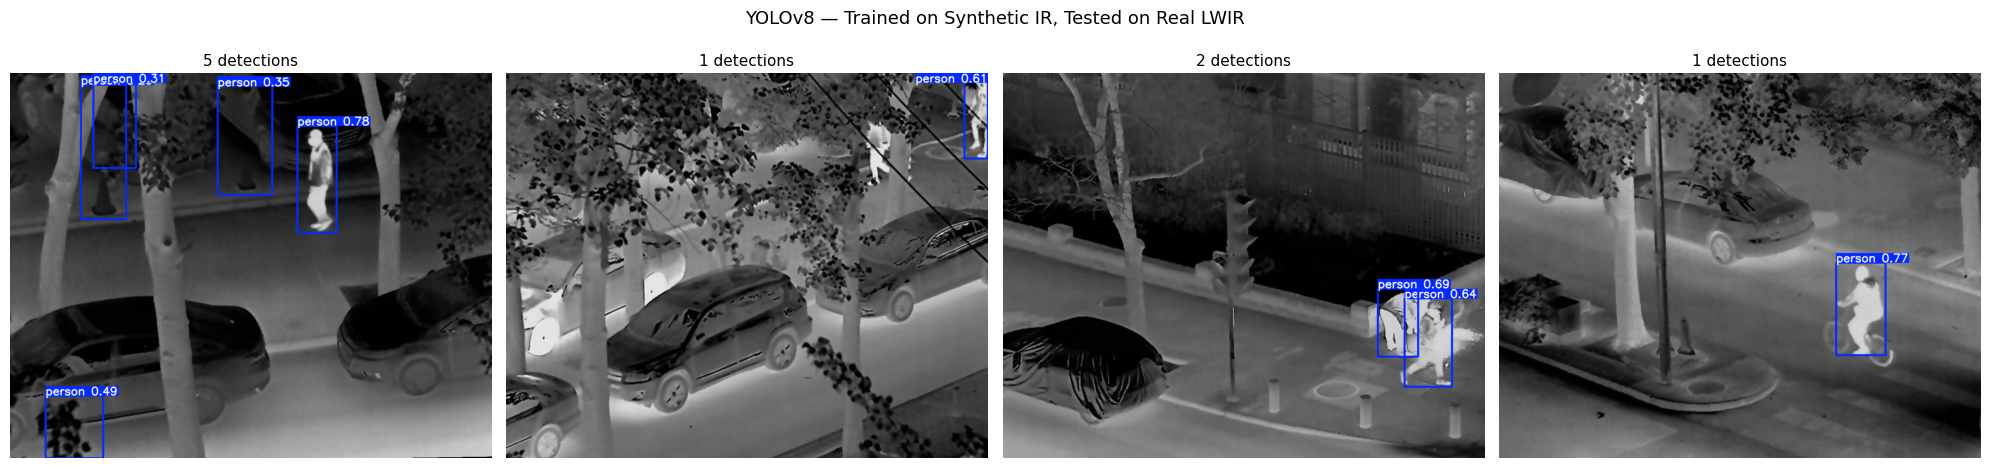

Saved to yolo_detection_results.png


In [18]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import random

model = YOLO('./runs/detect/runs/yolov8_synthetic_ir-2/weights/best.pt')

# Pick 4 random real LWIR images
val_imgs = list(Path('./yolo_dataset/val/images').glob('*'))
samples  = random.sample(val_imgs, min(4, len(val_imgs)))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, img_path in zip(axes, samples):
    results = model(str(img_path), verbose=False)
    annotated = results[0].plot()  # draws bounding boxes
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{len(results[0].boxes)} detections', fontsize=11)
    ax.axis('off')

plt.suptitle('YOLOv8 — Trained on Synthetic IR, Tested on Real LWIR', fontsize=13)
plt.tight_layout()
plt.savefig('./yolo_detection_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to yolo_detection_results.png')

## Step 11 — Save results to Google Drive

In [20]:
import shutil

DRIVE_RESULTS = '/content/drive/MyDrive/week2_yolo_results'
os.makedirs(DRIVE_RESULTS, exist_ok=True)

# Save best weights
shutil.copy(
    './runs/detect/runs/yolov8_synthetic_ir-2/weights/best.pt',
    f'{DRIVE_RESULTS}/yolov8_best.pt'
)

# Save detection visualization
shutil.copy('./yolo_detection_results.png', f'{DRIVE_RESULTS}/detection_results.png')

# Save training plots (loss curves, mAP curves)
plots_src = './runs/yolov8_synthetic_ir'
for f in Path(plots_src).glob('*.png'):
    shutil.copy(f, f'{DRIVE_RESULTS}/{f.name}')

print(f'All results saved to Google Drive: {DRIVE_RESULTS}')

All results saved to Google Drive: /content/drive/MyDrive/week2_yolo_results


In [21]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

DRIVE_RESULTS = '/content/drive/MyDrive/week2_yolo_results'
os.makedirs(DRIVE_RESULTS, exist_ok=True)

shutil.copy(
    './runs/detect/runs/yolov8_synthetic_ir-2/weights/best.pt',
    f'{DRIVE_RESULTS}/yolov8_best.pt'
)

shutil.copy('./yolo_detection_results.png', f'{DRIVE_RESULTS}/detection_results.png')

from pathlib import Path
for f in Path('./runs/detect/runs/yolov8_synthetic_ir-2').glob('*.png'):
    shutil.copy(f, f'{DRIVE_RESULTS}/{f.name}')

print(f'All saved to Google Drive: {DRIVE_RESULTS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All saved to Google Drive: /content/drive/MyDrive/week2_yolo_results
